In [7]:
import os

base_path = 'dataset'

print("📁 Estructura del dataset:\n")

for item in os.listdir(base_path):
    item_path = os.path.join(base_path, item)
    if os.path.isdir(item_path):
        print(f"└── {item}/")
        subitems = os.listdir(item_path)[:10]  # Primeros 10 items
        for subitem in subitems:
            subitem_path = os.path.join(item_path, subitem)
            if os.path.isdir(subitem_path):
                n_files = len(os.listdir(subitem_path))
                print(f"    └── {subitem}/ ({n_files} archivos)")
            else:
                print(f"    └── {subitem}")

📁 Estructura del dataset:

└── images/
    └── train/ (16 archivos)
    └── val/ (4 archivos)
└── labels/
    └── train/ (16 archivos)
    └── train.cache
    └── val/ (4 archivos)
    └── val.cache


In [1]:
from ultralytics import YOLO

# Usar modelo de segmentación en lugar de clasificación
model = YOLO('yolo11s-seg.pt')  # ← Cambio aquí: -seg en lugar de -cls

results = model.train(
    data='dataset/data.yaml',  
    epochs=50,
    imgsz=640,  # Tamaño típico para segmentación
    batch=16,
    name='segmentacion_exp'
)

New https://pypi.org/project/ultralytics/8.4.7 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.1  Python-3.13.2 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4070, 12282MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=segmentacion_exp, nbs=64, 

In [ ]:
'''
import yaml

dataset_path = 'ActividadSegmentacion_Carmen/dataset'

# Detectar número de clases automáticamente desde las etiquetas
import os

label_file = os.path.join(dataset_path, 'labels/train', os.listdir(f'{dataset_path}/labels/train')[0])
with open(label_file, 'r') as f:
    classes = set()
    for line in f:
        class_id = int(line.split()[0])
        classes.add(class_id)

nc = len(classes)

# Crear el YAML
data_config = {
    'path': dataset_path,
    'train': 'images/train',
    'val': 'images/val',
    'nc': nc,
    'names': {i: f'clase_{i}' for i in range(nc)}  # Ajusta los nombres reales
}

yaml_path = os.path.join(dataset_path, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, sort_keys=False)

print(f"✓ Archivo data.yaml creado con {nc} clases")
print(f"📄 Ubicación: {yaml_path}")

'''

'\nimport yaml\n\ndataset_path = \'ActividadSegmentacion_Carmen/dataset\'\n\n# Detectar número de clases automáticamente desde las etiquetas\nimport os\n\nlabel_file = os.path.join(dataset_path, \'labels/train\', os.listdir(f\'{dataset_path}/labels/train\')[0])\nwith open(label_file, \'r\') as f:\n    classes = set()\n    for line in f:\n        class_id = int(line.split()[0])\n        classes.add(class_id)\n\nnc = len(classes)\n\n# Crear el YAML\ndata_config = {\n    \'path\': dataset_path,\n    \'train\': \'images/train\',\n    \'val\': \'images/val\',\n    \'nc\': nc,\n    \'names\': {i: f\'clase_{i}\' for i in range(nc)}  # Ajusta los nombres reales\n}\n\nyaml_path = os.path.join(dataset_path, \'data.yaml\')\nwith open(yaml_path, \'w\') as f:\n    yaml.dump(data_config, f, sort_keys=False)\n\nprint(f"✓ Archivo data.yaml creado con {nc} clases")\nprint(f"📄 Ubicación: {yaml_path}")\n\n'

📁 Resultados en: runs/segment/segmentacion_exp

📊 VISUALIZACIONES

Curvas de entrenamiento:


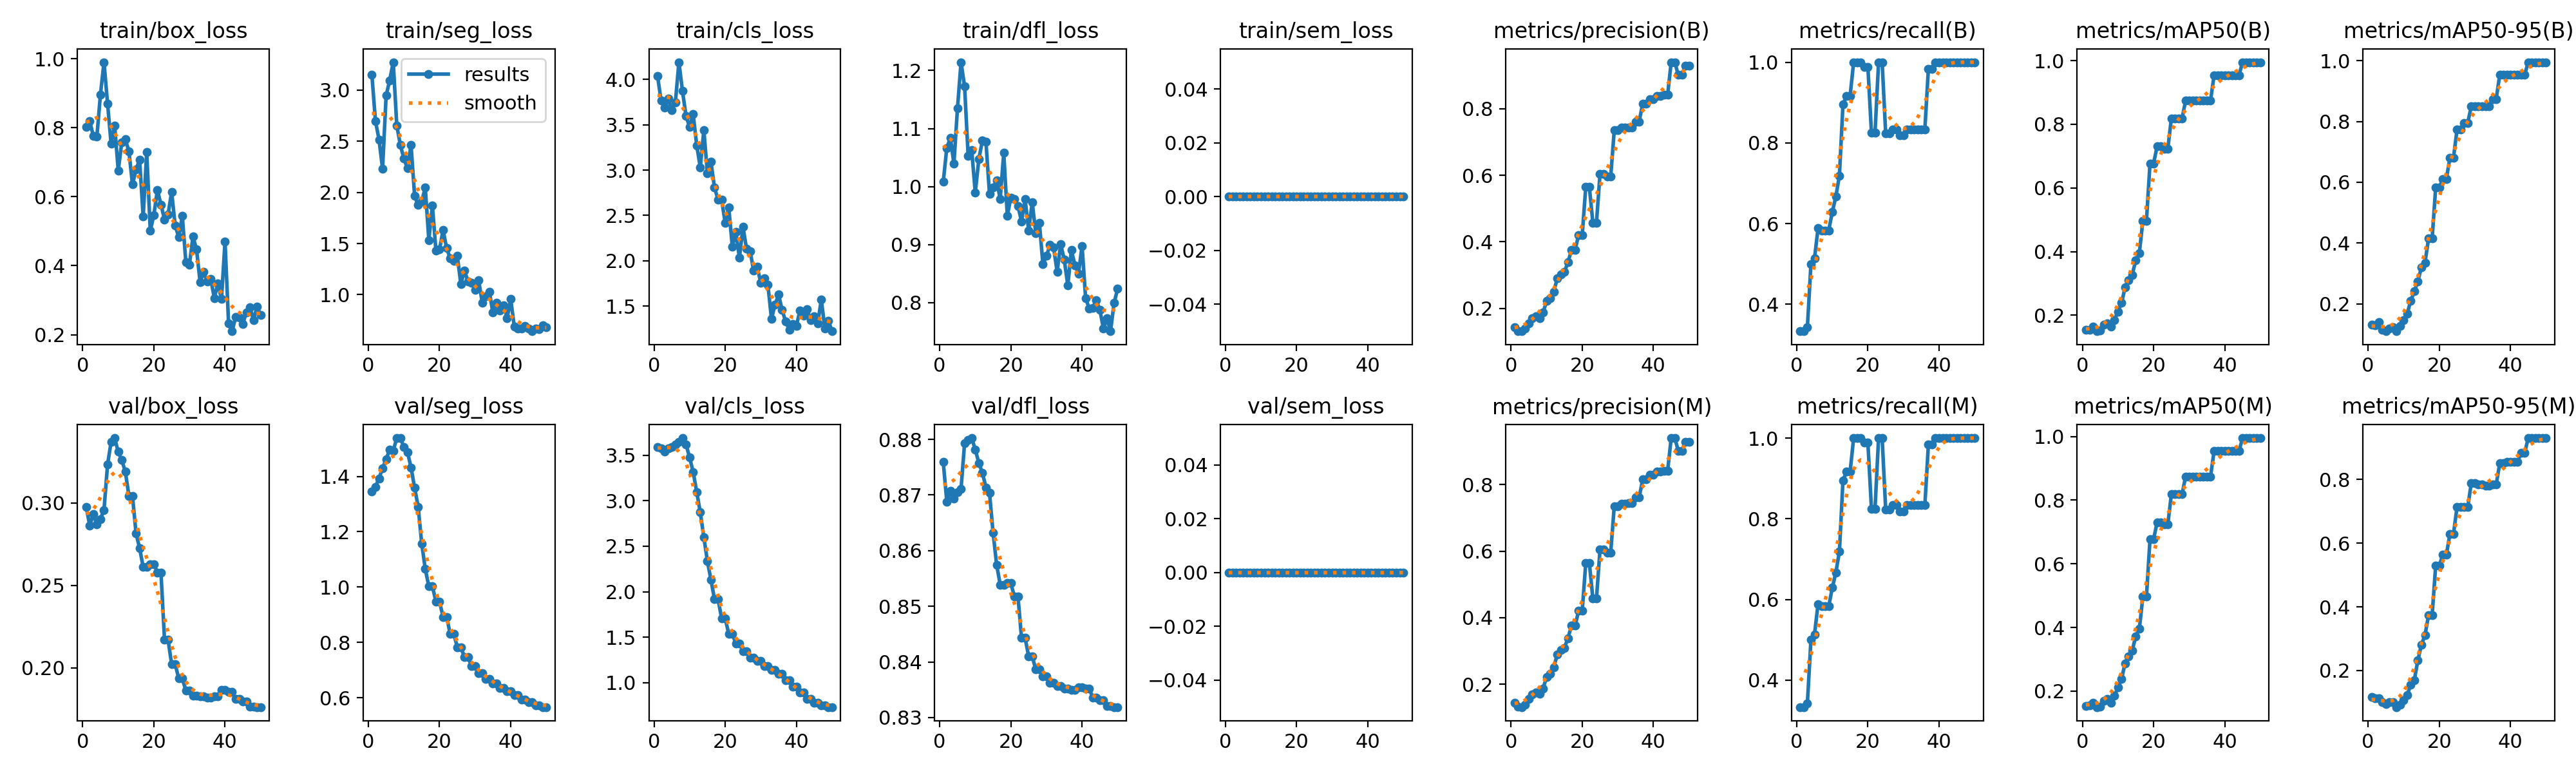


Predicciones de validación:


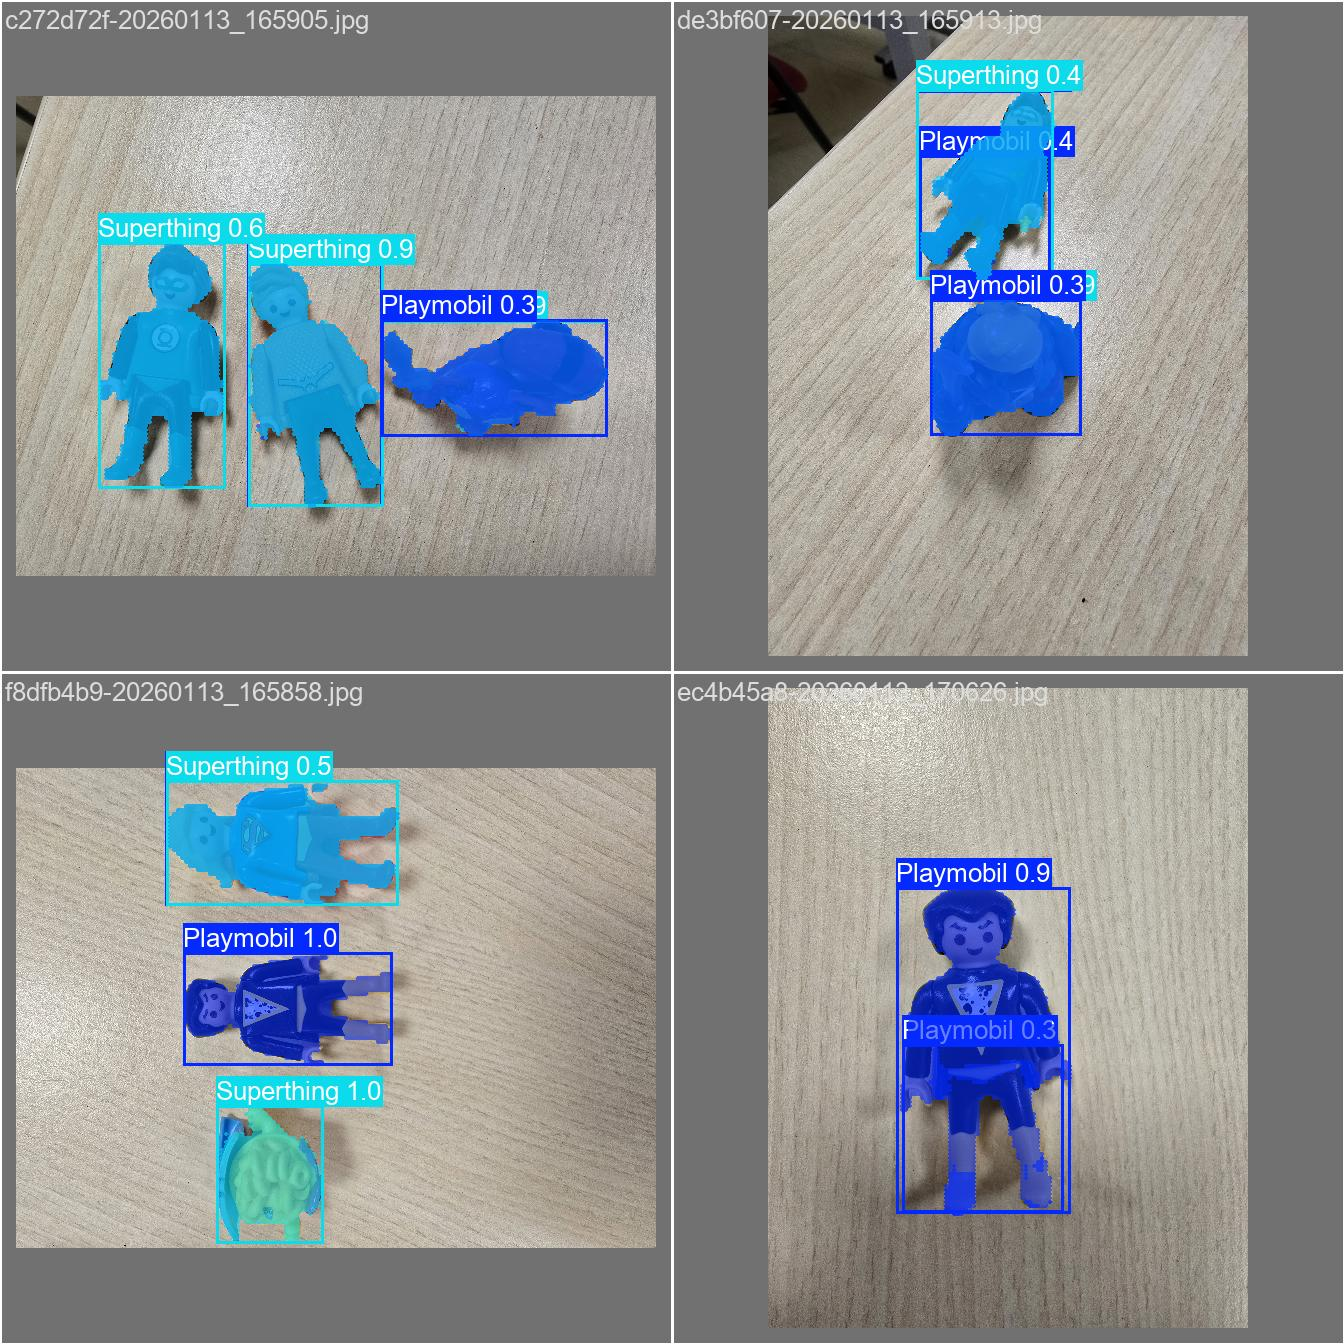


Ground Truth:


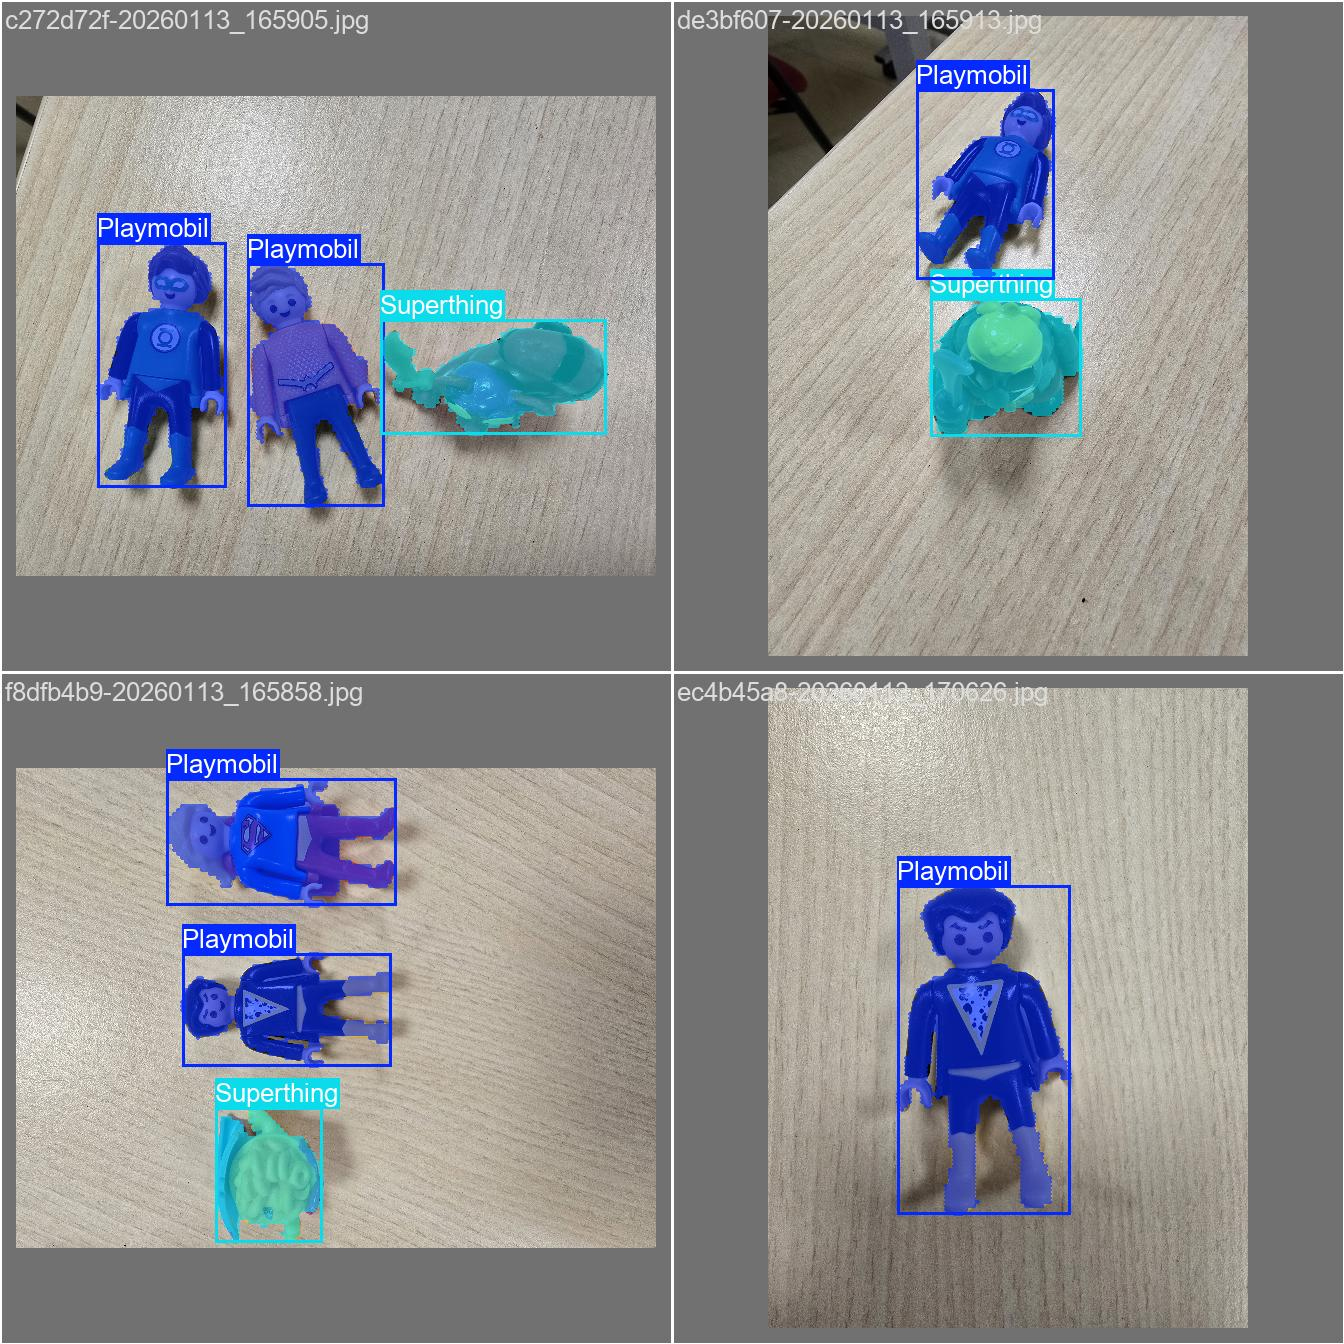


Matriz de confusión:


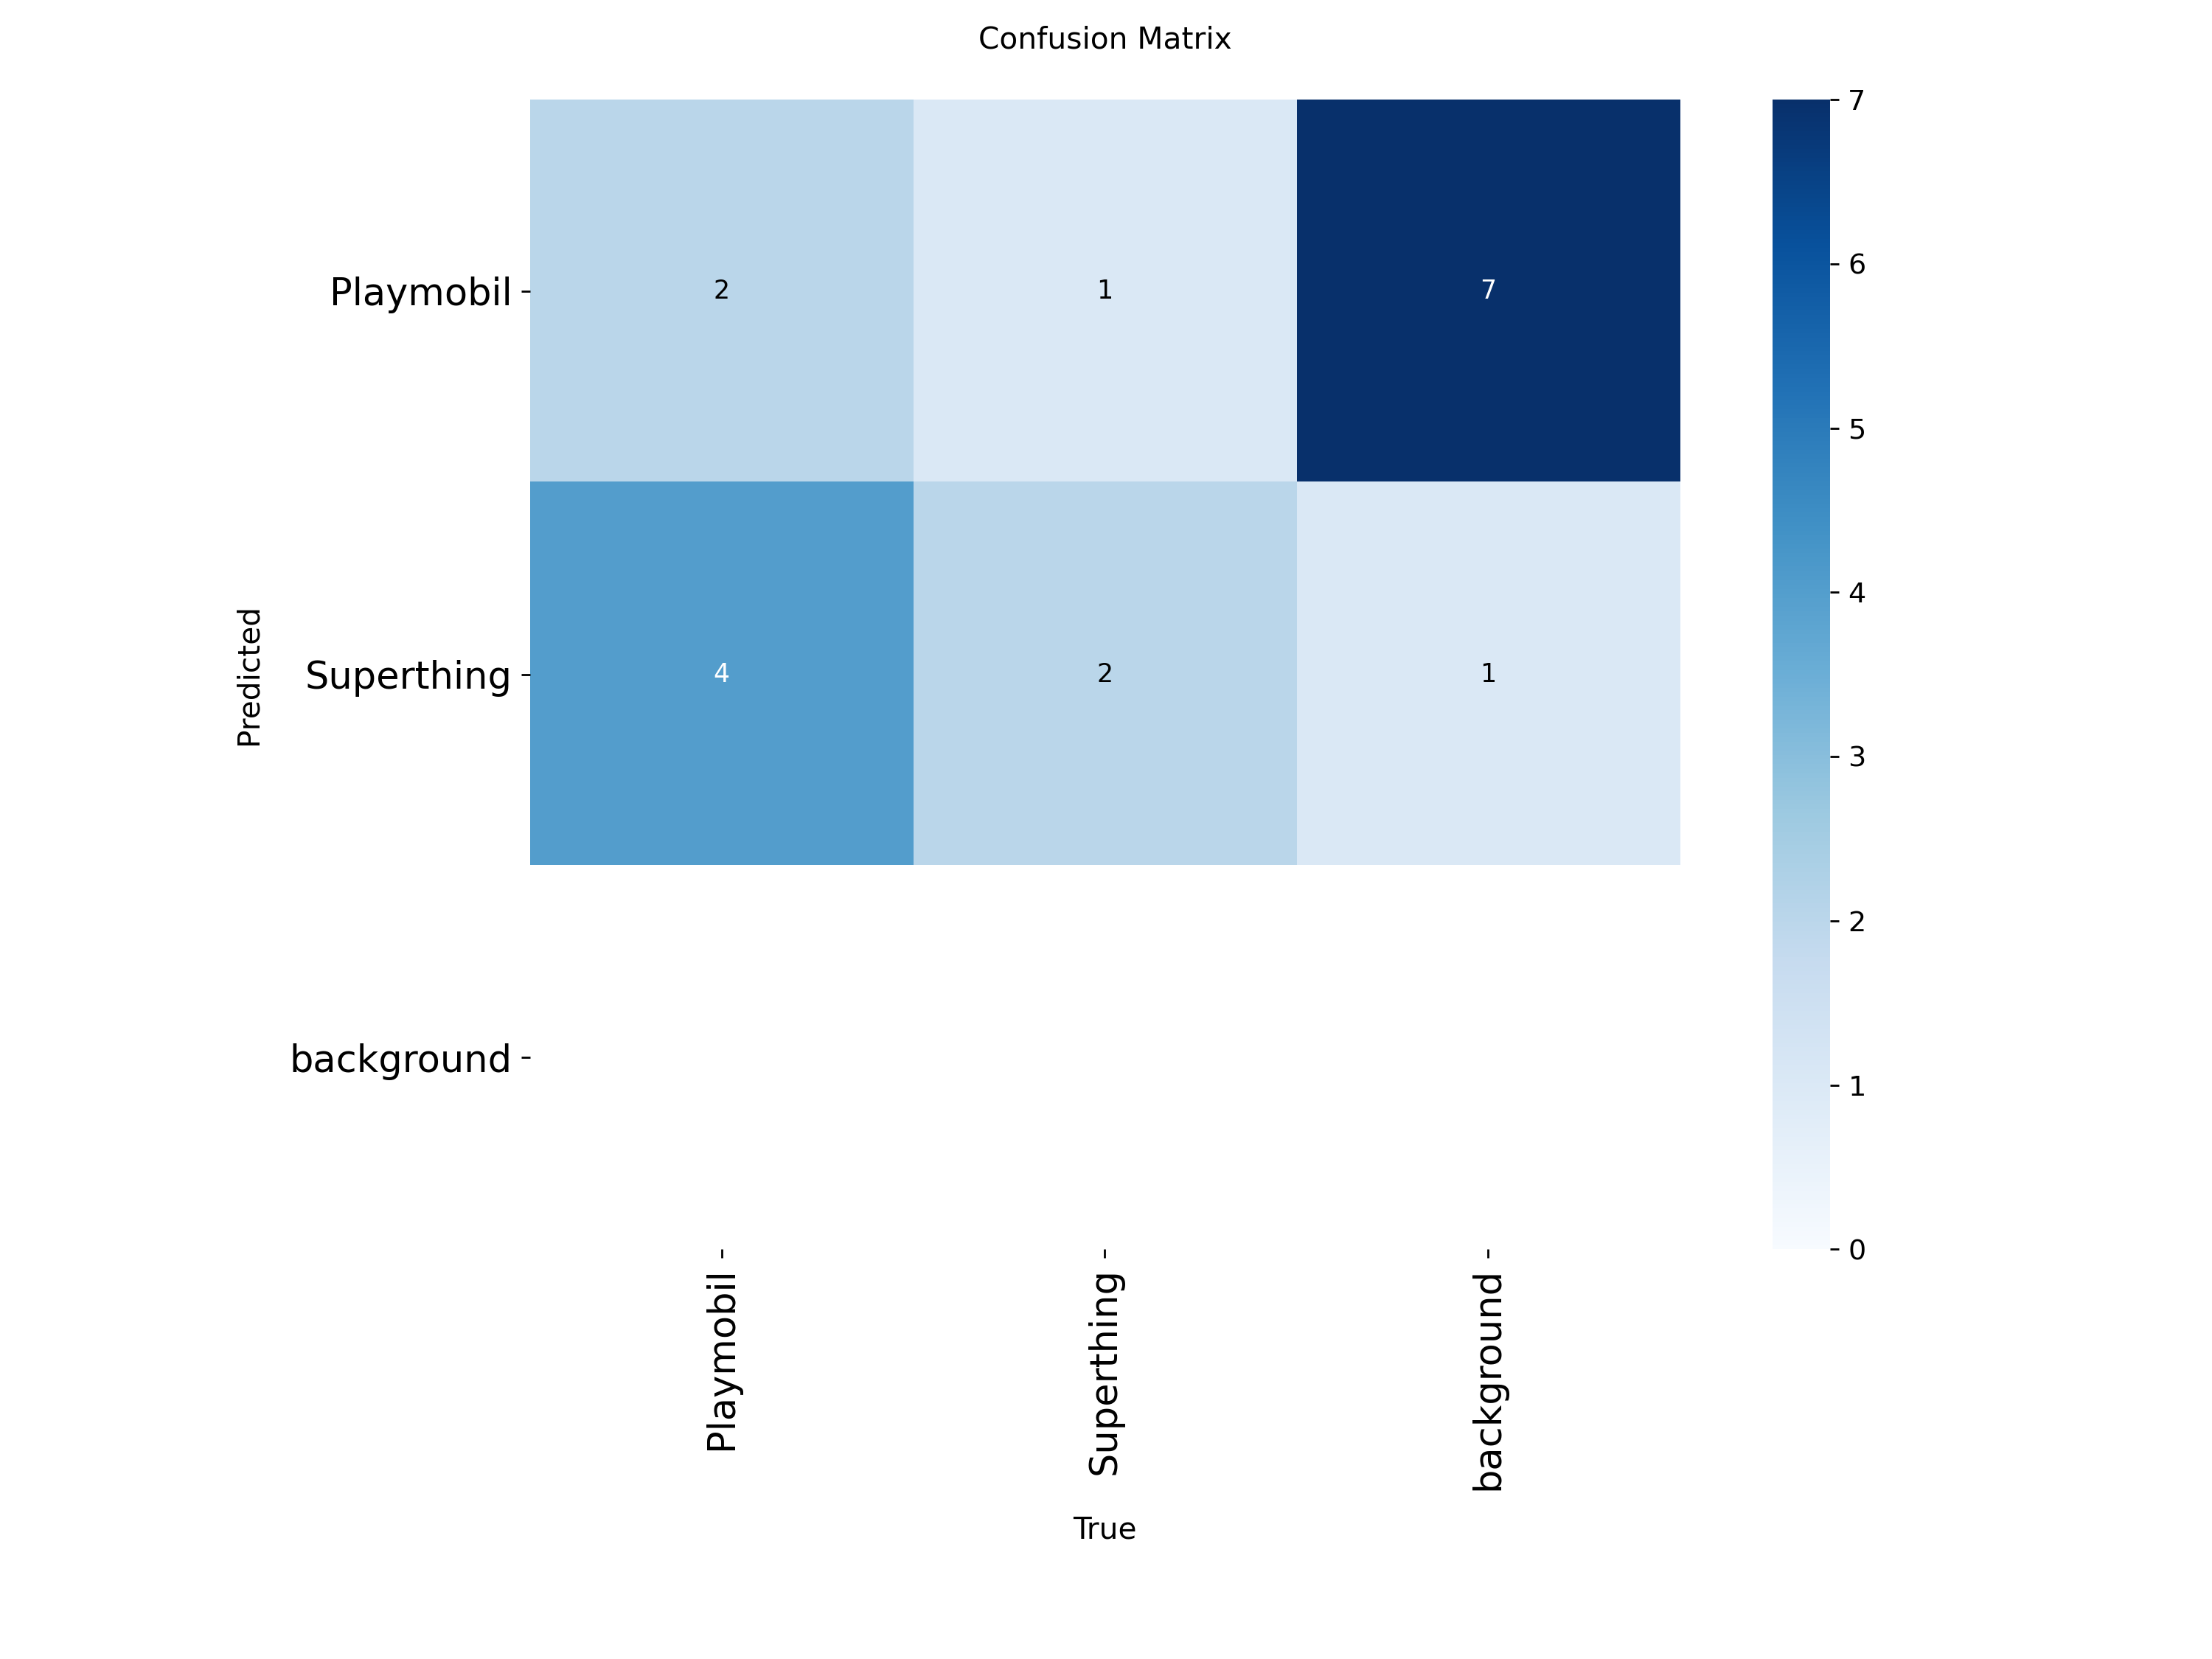


📈 MÉTRICAS FINALES

Época final: 50
mAP50 (Detección): 0.9950
mAP50-95 (Detección): 0.9950
mAP50 (Segmentación): 0.9950
mAP50-95 (Segmentación): 0.9298

✅ ¡Entrenamiento completado!
Mejor modelo guardado en: runs/segment/segmentacion_exp/weights/best.pt


In [2]:
import os
from IPython.display import Image, display
import pandas as pd
import matplotlib.pyplot as plt

# Ruta a resultados
exp_name = 'segmentacion_exp'
results_path = f'runs/segment/{exp_name}'

print(f"📁 Resultados en: {results_path}\n")

# 1. Mostrar imágenes principales
print("="*60)
print("📊 VISUALIZACIONES")
print("="*60)

imgs = {
    'Curvas de entrenamiento': 'results.png',
    'Predicciones de validación': 'val_batch0_pred.jpg',
    'Ground Truth': 'val_batch0_labels.jpg',
    'Matriz de confusión': 'confusion_matrix.png'
}

for titulo, archivo in imgs.items():
    path = f'{results_path}/{archivo}'
    if os.path.exists(path):
        print(f"\n{titulo}:")
        display(Image(filename=path, width=800))

# 2. Métricas finales
print("\n" + "="*60)
print("📈 MÉTRICAS FINALES")
print("="*60)

df = pd.read_csv(f'{results_path}/results.csv')
ultima_epoca = df.iloc[-1]

print(f"\nÉpoca final: {int(ultima_epoca['epoch'])}")
print(f"mAP50 (Detección): {ultima_epoca['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95 (Detección): {ultima_epoca['metrics/mAP50-95(B)']:.4f}")
print(f"mAP50 (Segmentación): {ultima_epoca['metrics/mAP50(M)']:.4f}")
print(f"mAP50-95 (Segmentación): {ultima_epoca['metrics/mAP50-95(M)']:.4f}")

print("\n✅ ¡Entrenamiento completado!")
print(f"Mejor modelo guardado en: {results_path}/weights/best.pt")

¿Describe cuáles son los elementos que presentan mayor 
complejidad de etiquetado/segmentación?  
- Oclusión parcial -- Confusión entre objetos
- Tamaño variable -- No detecta objetos pequeños
- Iluminación -- Falsos negativos
- Similitud entre clases -- Confusión de clases
- Fondos complejos -- Bounding boxes incorrectos
- Poses variadas -- No reconoce algunas poses
- Objetos múltiples -- Detecta varios como uno
- Bordes difusos -- Inconsistencia
- Dataset desbalanceado -- Sesgo del modelo